# Análisis Exploratorio de Datos (EDA)## Predicción de Brotes de Dengue en El Salvador### Universidad de El Salvador — IngenieríaEste notebook realiza el análisis exploratorio del **dataset v1 preliminar** que integradatos climáticos (NASA POWER) y epidemiológicos (MINSAL) a nivel departamental y semanal.Los datos se leen directamente desde el repositorio de GitHub, sin necesidad de subir archivos.**Objetivos del EDA:**1. Evaluar la cobertura y calidad de los datos por año2. Analizar la distribución y estacionalidad de los casos de dengue3. Explorar la relación entre variables climáticas y casos4. Identificar correlaciones y redundancias entre variables5. Detectar qué variables aportan valor y cuáles no6. Justificar con evidencia qué años incluir en el dataset final

## 1. Configuración e importación de librerías

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')
sns.set_palette('viridis')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

print('Librerías cargadas correctamente')

Librerías cargadas correctamente


## 2. Carga del dataset desde GitHubLos datos se leen directamente del repositorio DengueSV.

In [3]:
BASE = 'https://raw.githubusercontent.com/Melvillalta1/DengueSV/refs/heads/main/'
df = pd.read_csv(BASE + 'dataset_v1_preliminar.csv')

print(f'Dimensiones: {df.shape[0]:,} filas x {df.shape[1]} columnas')
df.head()

Dimensiones: 5,017 filas x 45 columnas


,anio_epi,semana_epi,departamento,casos_confirmados,casos_probables,casos_total,t2m_max_sem,t2m_min_sem,t2m_prom_sem,precip_total,precip_dias_lluvia,humedad_prom,viento_prom,t2m_prom_sem_lag1,t2m_prom_sem_lag2,t2m_prom_sem_lag3,t2m_prom_sem_lag4,precip_total_lag1,precip_total_lag2,precip_total_lag3,precip_total_lag4,humedad_prom_lag1,humedad_prom_lag2,humedad_prom_lag3,humedad_prom_lag4,t2m_max_sem_lag1,t2m_max_sem_lag2,t2m_max_sem_lag3,t2m_max_sem_lag4,amplitud_termica,grados_dia,en_rango_optimo,temp_bajo_letal_frio,temp_sobre_estres_calor,dist_temp_optima,semana_lluviosa,estacion_lluviosa,semana_sin,semana_cos,casos_total_lag1,casos_total_lag2,casos_total_lag3,casos_total_lag4,casos_tendencia,casos_promedio_4sem
0,2015,3,Ahuachapan,1.0,NaN,1,30.34,18.43,23.825714,0.63,2,68.407143,3.180000,24.152857,23.258571,24.300000,NaN,1.14,0.77,0.08,NaN,68.732857,68.280000,69.490000,NaN,30.77,31.27,30.94,NaN,11.91,13.825714,1,0,0,3.174286,0,0,0.354605,0.935016,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,4,Ahuachapan,1.0,NaN,1,29.18,15.73,21.481429,0.45,1,64.960000,6.922857,23.825714,24.152857,23.258571,24.300000,0.63,1.14,0.77,0.08,68.407143,68.732857,68.280000,69.490000,30.34,30.77,31.27,30.94,13.45,11.481429,0,0,0,5.518571,0,0,0.464723,0.885456,1.0,NaN,NaN,NaN,NaN,1.00
2,2015,5,Ahuachapan,1.0,NaN,1,31.74,18.05,23.854286,0.92,2,64.221429,4.332857,21.481429,23.825714,24.152857,23.258571,0.45,0.63,1.14,0.77,64.960000,68.407143,68.732857,68.280000,29.18,30.34,30.77,31.27,13.69,13.854286,1,0,0,3.145714,0,0,0.568065,0.822984,1.0,1.0,NaN,NaN,0.0,1.00
3,2015,6,Ahuachapan,0.0,NaN,0,31.05,17.00,23.294286,0.48,2,63.397143,4.111429,23.854286,21.481429,23.825714,24.152857,0.92,0.45,0.63,1.14,64.221429,64.960000,68.407143,68.732857,31.74,29.18,30.34,30.77,14.05,13.294286,1,0,0,3.705714,0,0,0.663123,0.748511,1.0,1.0,1.0,NaN,0.0,1.00
4,2015,7,Ahuachapan,1.0,NaN,1,32.29,17.21,23.641429,1.30,2,62.757143,4.852857,23.294286,23.854286,21.481429,23.825714,0.48,0.92,0.45,0.63,63.397143,64.221429,64.960000,68.407143,31.05,31.74,29.18,30.34,15.08,13.641429,1,0,0,3.358571,0,0,0.748511,0.663123,0.0,1.0,1.0,1.0,-1.0,0.75


## 3. Estructura y tipos de datos

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5017 entries, 0 to 5016
Data columns (total 45 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   anio_epi                 5017 non-null   int64  
 1   semana_epi               5017 non-null   int64  
 2   departamento             5017 non-null   object 
 3   casos_confirmados        4822 non-null   float64
 4   casos_probables          3516 non-null   float64
 5   casos_total              5017 non-null   int64  
 6   t2m_max_sem              5017 non-null   float64
 7   t2m_min_sem              5017 non-null   float64
 8   t2m_prom_sem             5017 non-null   float64
 9   precip_total             5017 non-null   float64
 10  precip_dias_lluvia       5017 non-null   int64  
 11  humedad_prom             5017 non-null   float64
 12  viento_prom              5017 non-null   float64
 13  t2m_prom_sem_lag1        5017 non-null   float64
 14  t2m_prom_sem_lag2       

In [5]:
df.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
anio_epi,5017.0,2018.41,2.39,2015.00,2016.00,2018.00,2020.00,2023.00
semana_epi,5017.0,28.42,14.35,1.00,16.00,29.00,41.00,52.00
casos_confirmados,4822.0,2.30,15.53,0.00,0.00,0.00,0.00,433.00
casos_probables,3516.0,0.33,1.38,0.00,0.00,0.00,0.00,39.00
casos_total,5017.0,2.45,15.28,0.00,0.00,0.00,1.00,433.00
t2m_max_sem,5017.0,31.84,2.64,26.12,29.74,31.33,33.77,39.92
t2m_min_sem,5017.0,21.29,2.37,12.77,19.73,21.49,23.21,26.23
t2m_prom_sem,5017.0,25.89,1.86,18.62,24.59,25.97,27.14,31.62
precip_total,5017.0,32.32,36.96,0.00,1.99,20.91,51.90,277.63
precip_dias_lluvia,5017.0,5.26,2.34,0.00,4.00,7.00,7.00,7.00


## 4. Cobertura y calidad por añoEste es uno de los análisis más importantes: nos dice qué años tienen datoscompletos y cuáles están incompletos, para justificar qué incluir en el modelo final.

In [6]:
cobertura = df.groupby('anio_epi').agg(
    filas=('departamento', 'count'),
    departamentos=('departamento', 'nunique'),
    semanas=('semana_epi', 'nunique'),
    casos_totales=('casos_total', 'sum'),
).reset_index()
cobertura['cobertura_%'] = (cobertura['filas'] / 728 * 100).round(1)
cobertura

,anio_epi,filas,departamentos,semanas,casos_totales,cobertura_%
0,2015,644,14,46,10155,88.5
1,2016,658,14,47,129,90.4
2,2017,700,14,50,222,96.2
3,2018,700,14,50,848,96.2
4,2019,728,14,52,633,100.0
5,2020,597,13,52,36,82.0
6,2021,206,8,42,52,28.3
7,2022,472,12,48,93,64.8
8,2023,312,13,46,108,42.9


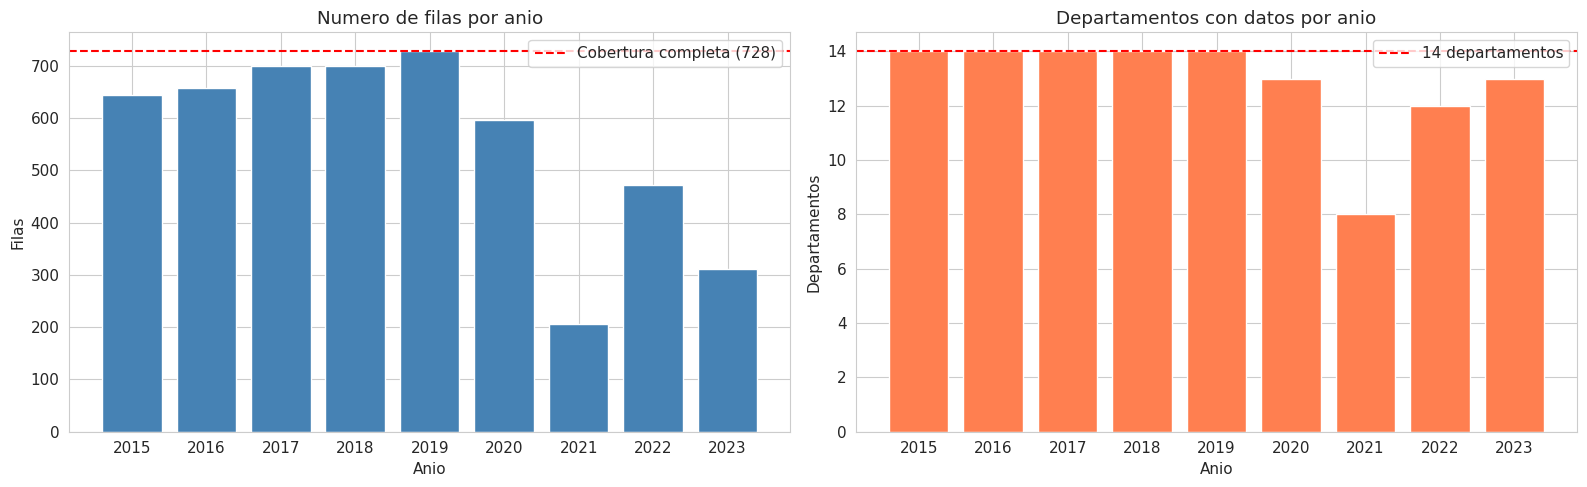

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].bar(cobertura['anio_epi'].astype(str), cobertura['filas'], color='steelblue')
axes[0].axhline(728, color='red', linestyle='--', label='Cobertura completa (728)')
axes[0].set_title('Numero de filas por anio')
axes[0].set_xlabel('Anio'); axes[0].set_ylabel('Filas'); axes[0].legend()

axes[1].bar(cobertura['anio_epi'].astype(str), cobertura['departamentos'], color='coral')
axes[1].axhline(14, color='red', linestyle='--', label='14 departamentos')
axes[1].set_title('Departamentos con datos por anio')
axes[1].set_xlabel('Anio'); axes[1].set_ylabel('Departamentos'); axes[1].legend()
plt.tight_layout(); plt.show()

**Interpretación esperada:** Los años 2021 (8 deptos), 2022 y 2023 muestrancobertura incompleta. Documenta aquí tu decisión sobre qué años conservar.

## 5. Distribución de los casos de dengue

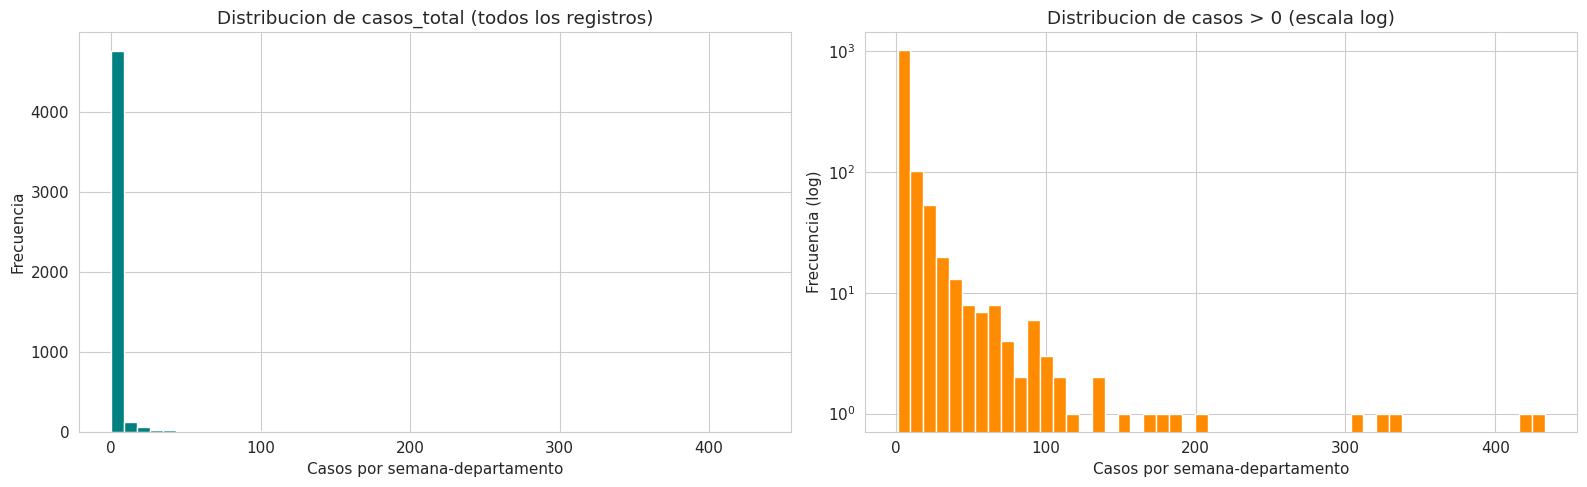

Semanas-departamento con 0 casos: 3,757 (74.9%)
Casos maximos en una semana-depto: 433
Media de casos: 2.45
Mediana de casos: 0


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].hist(df['casos_total'], bins=50, color='teal', edgecolor='white')
axes[0].set_title('Distribucion de casos_total (todos los registros)')
axes[0].set_xlabel('Casos por semana-departamento'); axes[0].set_ylabel('Frecuencia')

axes[1].hist(df[df['casos_total'] > 0]['casos_total'], bins=50, color='darkorange', edgecolor='white')
axes[1].set_yscale('log')
axes[1].set_title('Distribucion de casos > 0 (escala log)')
axes[1].set_xlabel('Casos por semana-departamento'); axes[1].set_ylabel('Frecuencia (log)')
plt.tight_layout(); plt.show()

print(f"Semanas-departamento con 0 casos: {(df['casos_total']==0).sum():,} ({(df['casos_total']==0).mean()*100:.1f}%)")
print(f"Casos maximos en una semana-depto: {df['casos_total'].max()}")
print(f"Media de casos: {df['casos_total'].mean():.2f}")
print(f"Mediana de casos: {df['casos_total'].median():.0f}")

**Nota metodológica:** El dengue típicamente tiene muchos ceros y una cola larga.Esta distribución sesgada es importante para elegir el modelo.

## 6. Estacionalidad: casos a lo largo del año

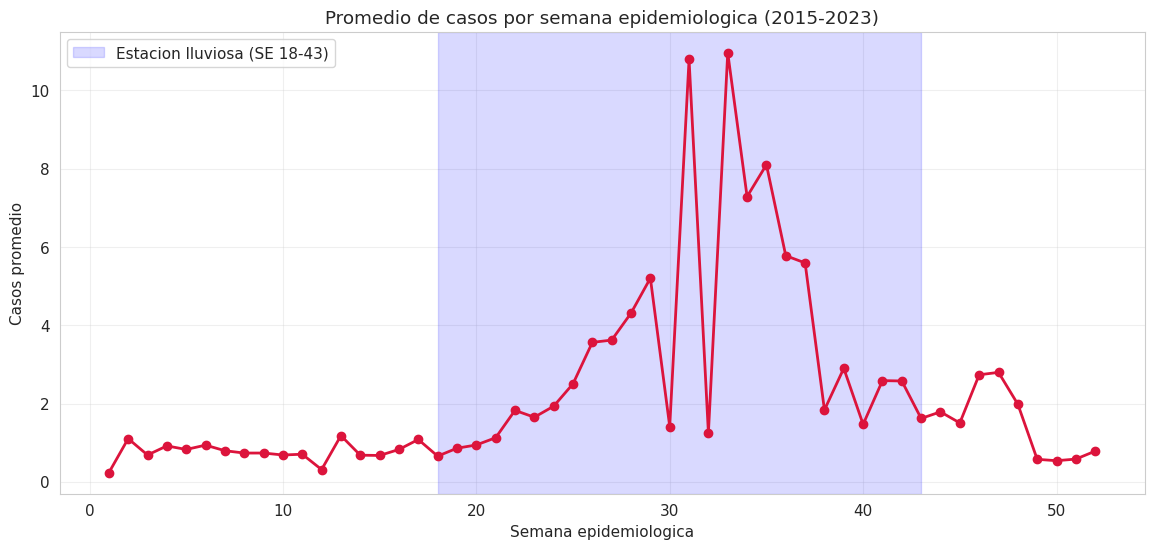

In [9]:
estacional = df.groupby('semana_epi')['casos_total'].mean()
plt.figure(figsize=(14, 6))
plt.plot(estacional.index, estacional.values, marker='o', color='crimson', linewidth=2)
plt.axvspan(18, 43, alpha=0.15, color='blue', label='Estacion lluviosa (SE 18-43)')
plt.title('Promedio de casos por semana epidemiologica (2015-2023)')
plt.xlabel('Semana epidemiologica'); plt.ylabel('Casos promedio')
plt.legend(); plt.grid(True, alpha=0.3); plt.show()

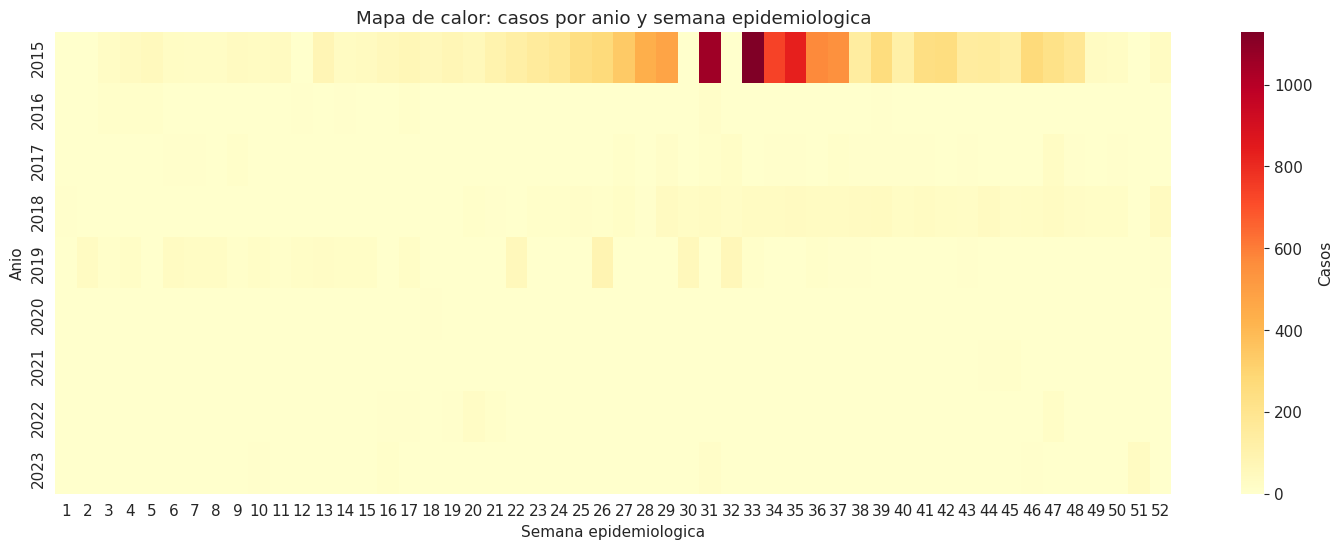

In [10]:
pivot = df.pivot_table(values='casos_total', index='anio_epi',
                        columns='semana_epi', aggfunc='sum', fill_value=0)
plt.figure(figsize=(18, 6))
sns.heatmap(pivot, cmap='YlOrRd', cbar_kws={'label': 'Casos'})
plt.title('Mapa de calor: casos por anio y semana epidemiologica')
plt.xlabel('Semana epidemiologica'); plt.ylabel('Anio'); plt.show()

## 7. Casos por departamento

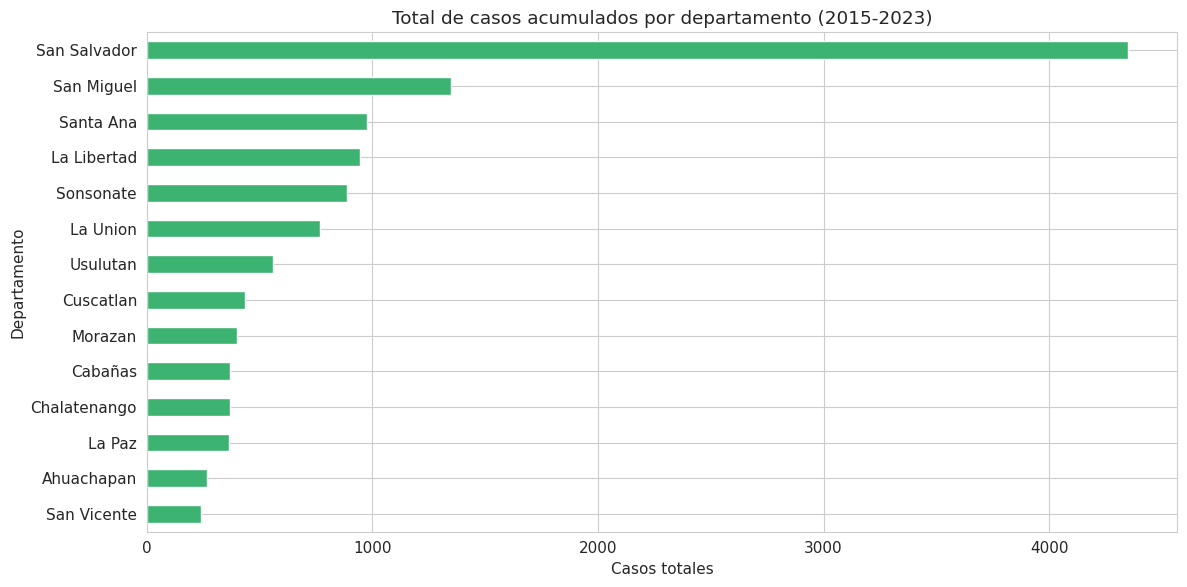

In [11]:
por_depto = df.groupby('departamento')['casos_total'].sum().sort_values(ascending=False)
plt.figure(figsize=(12, 6))
por_depto.plot(kind='barh', color='mediumseagreen')
plt.title('Total de casos acumulados por departamento (2015-2023)')
plt.xlabel('Casos totales'); plt.ylabel('Departamento')
plt.gca().invert_yaxis(); plt.tight_layout(); plt.show()

## 8. Comportamiento de las variables climáticas

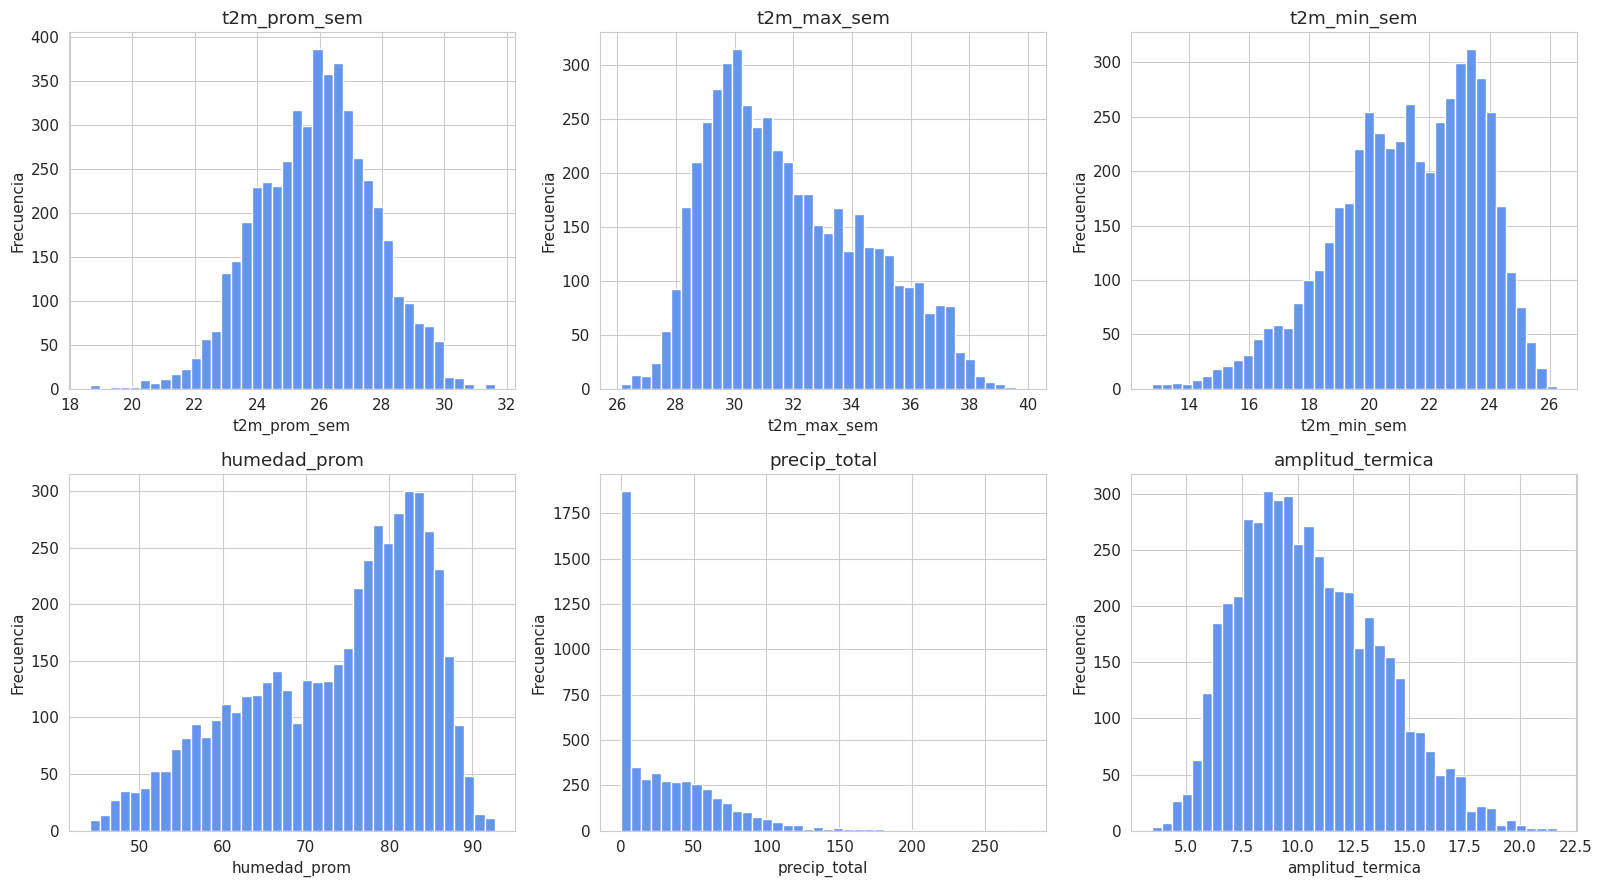

In [12]:
clima_vars = ['t2m_prom_sem', 't2m_max_sem', 't2m_min_sem',
              'humedad_prom', 'precip_total', 'amplitud_termica']
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, var in zip(axes.flat, clima_vars):
    ax.hist(df[var], bins=40, color='cornflowerblue', edgecolor='white')
    ax.set_title(var); ax.set_xlabel(var); ax.set_ylabel('Frecuencia')
plt.tight_layout(); plt.show()

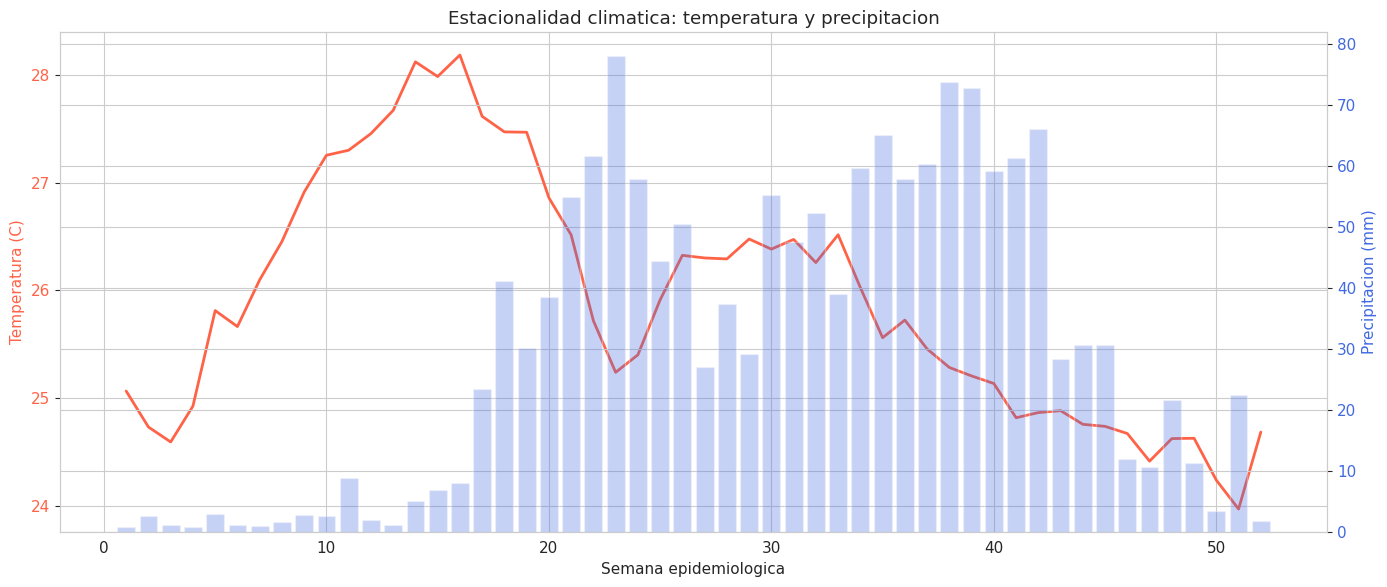

In [13]:
fig, ax1 = plt.subplots(figsize=(14, 6))
temp_sem = df.groupby('semana_epi')['t2m_prom_sem'].mean()
precip_sem = df.groupby('semana_epi')['precip_total'].mean()
ax1.plot(temp_sem.index, temp_sem.values, color='tomato', linewidth=2, label='Temp. promedio')
ax1.set_xlabel('Semana epidemiologica'); ax1.set_ylabel('Temperatura (C)', color='tomato')
ax1.tick_params(axis='y', labelcolor='tomato')
ax2 = ax1.twinx()
ax2.bar(precip_sem.index, precip_sem.values, alpha=0.3, color='royalblue', label='Precipitacion')
ax2.set_ylabel('Precipitacion (mm)', color='royalblue')
ax2.tick_params(axis='y', labelcolor='royalblue')
plt.title('Estacionalidad climatica: temperatura y precipitacion')
fig.tight_layout(); plt.show()

## 9. Relación entre clima y casos de dengue

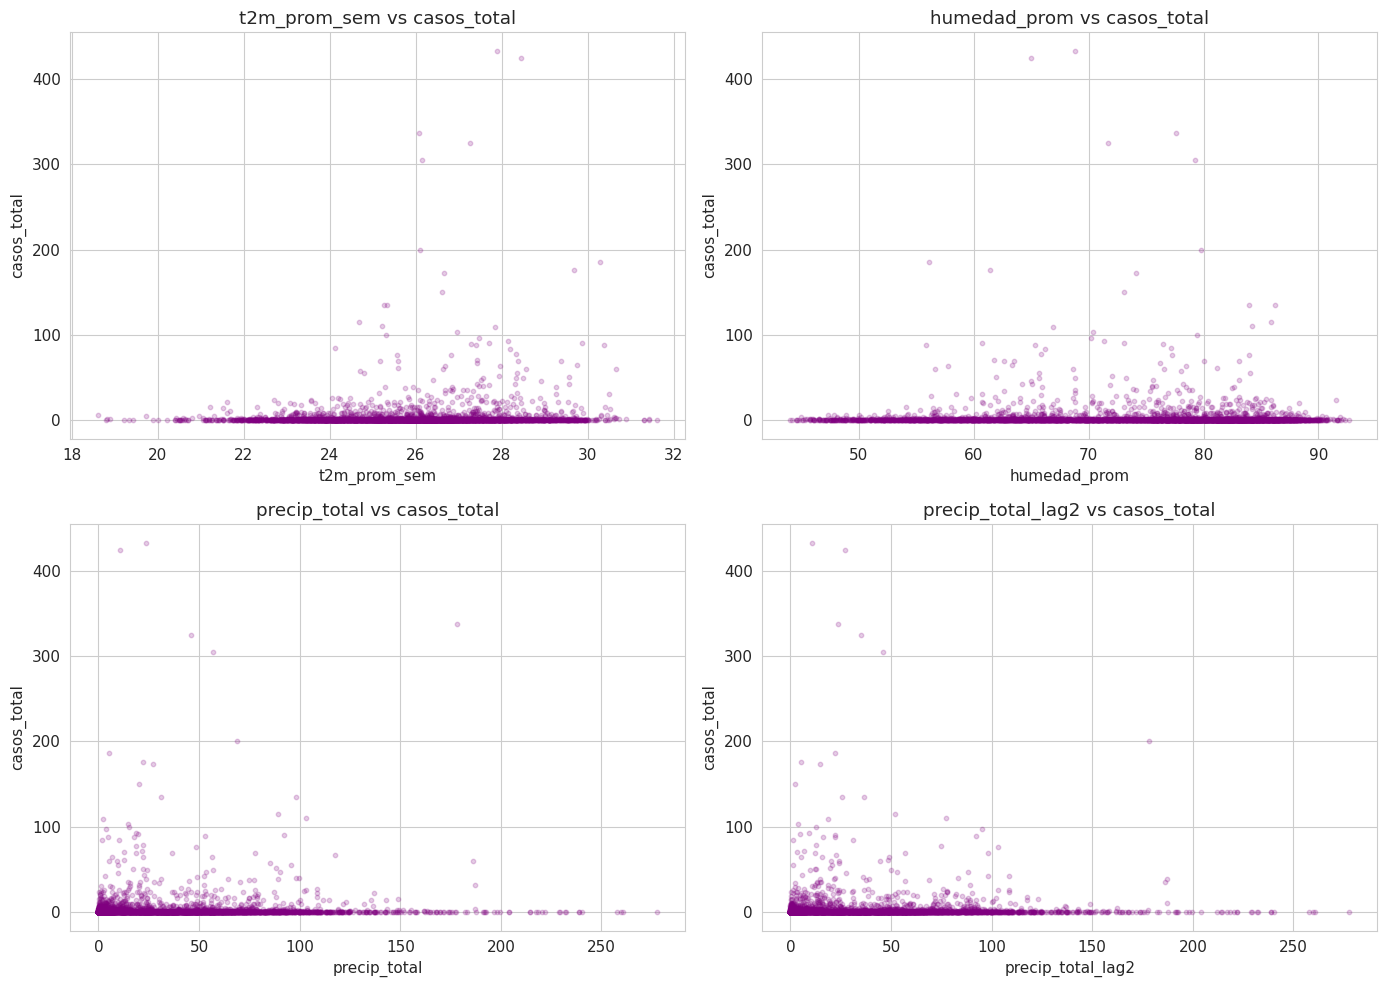

In [14]:
rel_vars = ['t2m_prom_sem', 'humedad_prom', 'precip_total', 'precip_total_lag2']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, var in zip(axes.flat, rel_vars):
    ax.scatter(df[var], df['casos_total'], alpha=0.2, s=10, color='purple')
    ax.set_xlabel(var); ax.set_ylabel('casos_total')
    ax.set_title(f'{var} vs casos_total')
plt.tight_layout(); plt.show()

## 10. Matriz de correlación

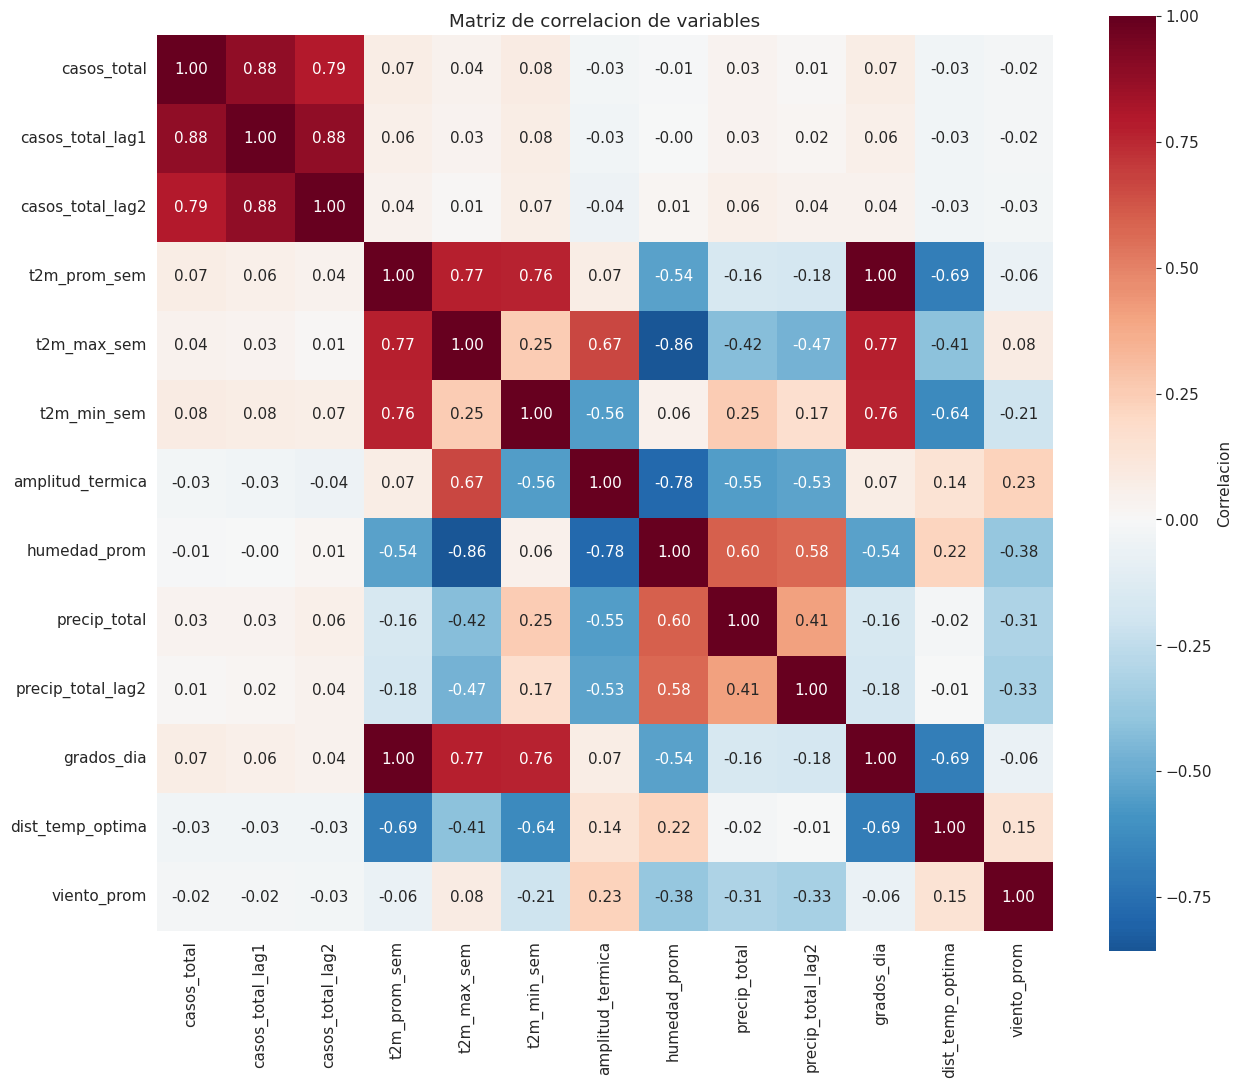

In [15]:
cols_corr = ['casos_total', 'casos_total_lag1', 'casos_total_lag2',
             't2m_prom_sem', 't2m_max_sem', 't2m_min_sem', 'amplitud_termica',
             'humedad_prom', 'precip_total', 'precip_total_lag2',
             'grados_dia', 'dist_temp_optima', 'viento_prom']
corr = df[cols_corr].corr()
plt.figure(figsize=(13, 11))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, cbar_kws={'label': 'Correlacion'})
plt.title('Matriz de correlacion de variables')
plt.tight_layout(); plt.show()

In [16]:
corr_casos = df[cols_corr].corr()['casos_total'].drop('casos_total').sort_values(ascending=False)
print('Correlacion de cada variable con casos_total:')
print(corr_casos.to_string())

Correlacion de cada variable con casos_total:
casos_total_lag1     0.877883
casos_total_lag2     0.790941
t2m_min_sem          0.082092
grados_dia           0.073039
t2m_prom_sem         0.073039
t2m_max_sem          0.043947
precip_total         0.032428
precip_total_lag2    0.010527
humedad_prom        -0.013494
viento_prom         -0.015565
amplitud_termica    -0.025601
dist_temp_optima    -0.030111


## 11. Variables con poca o nula varianza

In [17]:
binarias = ['en_rango_optimo', 'temp_bajo_letal_frio', 'temp_sobre_estres_calor',
            'semana_lluviosa', 'estacion_lluviosa']
print('Distribucion de variables binarias:')
for var in binarias:
    n1 = df[var].sum()
    pct = n1 / len(df) * 100
    print(f'  {var:28s}: {n1:>5} unos ({pct:5.1f}%)  |  {len(df)-n1:>5} ceros ({100-pct:5.1f}%)')

Distribucion de variables binarias:
  en_rango_optimo             :  4926 unos ( 98.2%)  |     91 ceros (  1.8%)
  temp_bajo_letal_frio        :     0 unos (  0.0%)  |   5017 ceros (100.0%)
  temp_sobre_estres_calor     :   755 unos ( 15.0%)  |   4262 ceros ( 85.0%)
  semana_lluviosa             :  2988 unos ( 59.6%)  |   2029 ceros ( 40.4%)
  estacion_lluviosa           :  2695 unos ( 53.7%)  |   2322 ceros ( 46.3%)


## 12. Conclusiones del EDA

**Patrón estacional marcado:** Los casos de dengue no se distribuyen de forma uniforme a lo largo del año, sino que se concentran claramente en la temporada lluviosa de El Salvador, aproximadamente entre las semanas epidemiológicas 18 y 43 (mayo a octubre). Durante este período la curva de casos promedio se eleva de forma sostenida, mientras que en las semanas de temporada seca (1-17 y 44-52) los casos se mantienen en niveles bajos.

**Años con cobertura completa:** Los años 2015 a 2020 presentan una cobertura sólida, con los 14 departamentos representados y entre 46 y 52 semanas epidemiológicas por año. El año 2019 es el más completo, con las 52 semanas y los 14 departamentos (728 registros).
**Años con pocos datos o problematicos:** El año 2021 es el más problemático, con solo 8 departamentos y 42 semanas (206 registros), una cobertura muy por debajo del resto. Los años 2022 (12 departamentos, 48 semanas) y 2023 (13 departamentos, 46 semanas) también presentan cobertura parcial. Estos años deben tratarse con precaución: pueden incluirse en el entrenamiento aportando datos, pero no son ideales como conjunto de evaluación por su baja densidad de casos y cobertura incompleta.
**Variable objetivo**
Los casos totales, presentan una distribución con muchos ceros y cola larga la varialbe está fuertemente sesgada hacia cero. La gran mayoría de los registros semana-departamento tienen entre 0 y pocos casos, mientras que existe una cola larga de pocos eventos extremos con valores muy altos (hasta más de 400 casos en una sola semana-departamento, concentrados en la epidemia de 2015). Esta distribución es la razon por la que se utilizo posteriormente una transformación logarítmica y de modelos robustos a valores extremos.

**Alta autocorrelación** los rezagos de casos son predictores clave: Los casos de una semana están fuertemente correlacionados con los de las semanas inmediatamente anteriores, reflejando la naturaleza autopropagante de la transmisión del dengue (cada persona infectada puede contagiar a más mosquitos, que contagian a más personas). Esto convierte a las variables rezagadas de casos en los predictores más relevantes del modelo.
